# Gasoline signals: what helps forecast the next build or draw?

Which monthly signals add value beyond the usual seasonal inventory pattern? The target is the next U.S. stock change in finished gasoline plus blending-component stocks. Positive means a build; negative means a draw. Errors are in million barrels.

Inputs use earlier monthly observations. EIA release delays and revisions mean this is a historical research test, not a release-day trading signal. A three-month lag check tests sensitivity to older information.

## Trading readout

The trailing three-month core balance is the leading addition to seasonality in development tests. The selected combination loses to the calendar benchmark in the final period. Treat that balance signal as a candidate to monitor, not a reason to override the seasonal view. The scorecard below updates when the notebook is rerun.

In [1]:
FUEL = 'gasoline'
from pathlib import Path
import sys, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sklearn
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 100)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'oil/us_snd_crude/crude_data.py').exists())
for fuel in ['crude', 'gasoline']:
    sys.path.insert(0, str(ROOT/f'oil/us_snd_{fuel}'))
from crude_data import load_panel as load_crude, FLOWS as CRUDE_FLOWS
from gasoline_data import load_panel as load_gasoline, FLOWS as GAS_FLOWS
panels = {'crude': load_crude(), 'gasoline': load_gasoline()}
national = {}
for fuel, panel in panels.items():
    assert panel.groupby('month').padd.nunique().eq(5).all()
    cols = (CRUDE_FLOWS + ['stock_kb', 'cdu_capacity_kbd']) if fuel == 'crude' else GAS_FLOWS + ['stock_kb']
    z = panel.groupby('month')[cols].sum(min_count=5).asfreq('MS')
    assert z.notna().all().all()
    # Every flow becomes thousand barrels/day; stocks become million barrels.
    if fuel == 'gasoline':
        for c in GAS_FLOWS:
            z[c.replace('_kb', '_kbd')] = z[c] / z.index.days_in_month
    z['stock_mb'] = z.stock_kb / 1000
    z['change_mb'] = z.stock_mb.diff()
    z['net_imports_kbd'] = z.imports_kbd - z.exports_kbd
    z['core_balance_kbd'] = z.production_kbd + z.net_imports_kbd - z.demand_kbd
    if fuel == 'crude':
        z['utilization'] = z.demand_kbd / z.cdu_capacity_kbd
    national[fuel] = z
manifest = []
for fuel in national:
    path = ROOT/f'oil/us_snd_{fuel}/data/eia_observations.csv'
    manifest.append({'fuel': fuel, 'start': national[fuel].index.min(), 'end': national[fuel].index.max(),
                     'months': len(national[fuel]), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
display(pd.DataFrame(manifest))
print('Python', platform.python_version(), '| pandas', pd.__version__, '| sklearn', sklearn.__version__)


,fuel,start,end,months,sha256
0,crude,2007-01-01,2026-06-01,234,d9eb20fae286737e399acc8151246437105aa71df066ed1338164a0c0c5026b1
1,gasoline,2007-01-01,2026-06-01,234,47b39e884223a433dc4fae806b2723b98df8837c91b356748894f98db28dbc5c


Python 3.13.9 | pandas 2.3.3 | sklearn 1.7.2


## Signals tested

Inventory history, production, demand, trade, and the other fuel's flows compete with the calendar. Flow inputs use thousand barrels/day; stocks and changes use million barrels.

The **core balance** is production + imports − exports − demand. It omits adjustments and regional receipts, plus other product-specific flows. It is a simplified signal, not the full S&D balance.

In [2]:
def outside_covid(dates):
    return ~((dates >= pd.Timestamp('2020-03-01')) & (dates <= pd.Timestamp('2021-03-01')))

def make_design(lag=1):
    z = national[FUEL]
    other = national['gasoline' if FUEL == 'crude' else 'crude'].reindex(z.index)
    X = pd.DataFrame(index=z.index)
    groups = {}
    # Full month indicators allow asymmetric seasonal builds/draws.
    for month in range(1, 13):
        X[f'month_{month:02}'] = (X.index.month == month).astype(float)
    groups['seasonality'] = list(X.columns)
    def add(group, name, series):
        X[name] = series
        groups.setdefault(group, []).append(name)
    for c in ['stock_mb', 'change_mb']:
        add('inventory_history', f'{c}_lag{lag}', z[c].shift(lag))
    add('inventory_history', 'stock_vs_year_ago', z.stock_mb.shift(lag)-z.stock_mb.shift(lag+12))
    add('inventory_history', 'change_mean3', z.change_mb.shift(lag).rolling(3).mean())
    for group, cols in {'supply': ['production_kbd'], 'demand': ['demand_kbd'],
                        'trade': ['imports_kbd', 'exports_kbd'],
                        'balance': ['core_balance_kbd'],
                        'other_flows': ['adjustments_kbd', 'net_receipts_kbd'] + (['transfers_kbd', 'direct_use_kbd'] if FUEL == 'crude' else ['biofuels_kbd'])}.items():
        for c in cols:
            add(group, f'{c}_lag{lag}', z[c].shift(lag))
            add(group, f'{c}_mean3', z[c].shift(lag).rolling(3).mean())
    if FUEL == 'crude':
        add('refinery_capacity', 'utilization_lag', z.utilization.shift(lag))
        add('refinery_capacity', 'capacity_lag', z.cdu_capacity_kbd.shift(lag))
    for c in ['demand_kbd', 'production_kbd', 'change_mb']:
        add('cross_fuel', f'other_{c}_lag', other[c].shift(lag))
    y = z.change_mb.rename('actual')
    keep = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[keep], y.loc[keep]
    # Conservative exclusion of every month in the maximum lookback window.
    eligible = outside_covid(X.index)
    for offset in range(lag, lag+13):
        eligible &= outside_covid(X.index-pd.DateOffset(months=offset))
    return X, y, groups, pd.Series(eligible, index=X.index)

X, y, groups, eligible = make_design()
HOLDOUT = pd.Timestamp('2024-07-01')
dev_dates = X.index[(X.index < HOLDOUT) & outside_covid(X.index)]
# Six expanding-window validation blocks, 12 scored months each.
folds = [pd.DatetimeIndex(a) for a in np.array_split(dev_dates[-72:], 6)]
display(pd.DataFrame([{'group': g, 'features': ', '.join(cols)} for g, cols in groups.items()]))
display(pd.DataFrame([{'fold': i+1, 'train_rows': int(((X.index < d.min()) & eligible).sum()),
                       'validation_start': d.min(), 'validation_end': d.max(), 'scored_months': len(d)} for i,d in enumerate(folds)]))
assert max(d.max() for d in folds) < HOLDOUT
assert X.index.is_monotonic_increasing and not X.index.has_duplicates
print('Target: next-month inventory change in million barrels; positive = build.')


,group,features
0,seasonality,"month_01, month_02, month_03, month_04, month_05, month_06, month_07, month_08, month_09, month_..."
1,inventory_history,"stock_mb_lag1, change_mb_lag1, stock_vs_year_ago, change_mean3"
2,supply,"production_kbd_lag1, production_kbd_mean3"
3,demand,"demand_kbd_lag1, demand_kbd_mean3"
4,trade,"imports_kbd_lag1, imports_kbd_mean3, exports_kbd_lag1, exports_kbd_mean3"
5,balance,"core_balance_kbd_lag1, core_balance_kbd_mean3"
6,other_flows,"adjustments_kbd_lag1, adjustments_kbd_mean3, net_receipts_kbd_lag1, net_receipts_kbd_mean3, biof..."
7,cross_fuel,"other_demand_kbd_lag, other_production_kbd_lag, other_change_mb_lag"


,fold,train_rows,validation_start,validation_end,scored_months
0,1,112,2017-06-01,2018-05-01,12
1,2,124,2018-06-01,2019-05-01,12
2,3,136,2019-06-01,2021-06-01,12
3,4,145,2021-07-01,2022-06-01,12
4,5,147,2022-07-01,2023-06-01,12
5,6,159,2023-07-01,2024-06-01,12


Target: next-month inventory change in million barrels; positive = build.


## Does the signal beat seasonality?

Six successive development windows choose the inputs and settings. Each forecast uses earlier observations. Calendar ridge fits month-of-year effects; the historical-month mean is another seasonal benchmark. Zero change means unchanged stocks (persistence).

The same windows select and rank candidates, so development gains may be optimistic.

In [3]:
def estimator(kind, alpha):
    if kind == 'ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    return RandomForestRegressor(n_estimators=160, min_samples_leaf=alpha, max_features=0.8, random_state=42, n_jobs=2)

def columns(group_names):
    return [c for g in group_names for c in groups[g]]

def evaluate(group_names, kind='ridge', alpha=10, blocks=None, design=None):
    xx, yy, ee = (X, y, eligible) if design is None else design
    rows = []
    for fold, dates in enumerate(folds if blocks is None else blocks):
        train = (xx.index < dates.min()) & ee
        assert xx.index[train].max() < dates.min()
        if kind in ['zero', 'seasonal_mean']:
            pred = np.zeros(len(dates)) if kind == 'zero' else pd.Series(yy[train]).groupby(yy[train].index.month).mean().reindex(dates.month).to_numpy()
        else:
            model = estimator(kind, alpha)
            model.fit(xx.loc[train, columns(group_names)], yy[train])
            pred = model.predict(xx.loc[dates, columns(group_names)])
        rows.append(pd.DataFrame({'month': dates, 'fold': fold+1, 'actual': yy.loc[dates].values, 'predicted': pred}))
    return pd.concat(rows, ignore_index=True)

def metrics(pred):
    return {'mae_mb': mean_absolute_error(pred.actual, pred.predicted),
            'rmse_mb': np.sqrt(mean_squared_error(pred.actual, pred.predicted)),
            'direction_accuracy': (np.mean(np.sign(pred.actual[pred.predicted.ne(0)]) == np.sign(pred.predicted[pred.predicted.ne(0)])) if pred.predicted.ne(0).any() else np.nan),
            'direction_call_coverage': np.mean(pred.predicted.ne(0))}

records, specs, cv_predictions = [], {}, {}
def candidate(name, gs, kind='ridge', alpha=10):
    p = evaluate(gs, kind, alpha)
    specs[name] = (gs, kind, alpha)
    cv_predictions[name] = p
    records.append({'candidate': name, **metrics(p)})

candidate('zero_change', [], 'zero')
candidate('historical_month_mean', [], 'seasonal_mean')
for alpha in [1, 10, 100]:
    candidate(f'calendar_ridge_{alpha}', ['seasonality'], alpha=alpha)
    candidate(f'all_ridge_{alpha}', list(groups), alpha=alpha)
    for group in list(groups)[1:]:
        candidate(f'calendar_plus_{group}_{alpha}', ['seasonality', group], alpha=alpha)
for leaf in [5, 15]:
    candidate(f'all_forest_leaf{leaf}', list(groups), 'forest', leaf)
leaderboard = pd.DataFrame(records).sort_values('mae_mb').reset_index(drop=True)
# Greedy additions use development data only, capped at three noncalendar groups.
chosen = ['seasonality']
for step in range(3):
    options = []
    for group in groups:
        if group in chosen: continue
        for alpha in [1, 10, 100]:
            name = f'forward{step+1}_{group}_{alpha}'
            candidate(name, chosen+[group], alpha=alpha)
            options.append(records[-1])
    best = min(options, key=lambda r:r['mae_mb'])
    chosen = specs[best['candidate']][0]
leaderboard = pd.DataFrame(records).sort_values('mae_mb').reset_index(drop=True)
winner = leaderboard.iloc[0].candidate
print('Frozen development winner:', winner, specs[winner])
display(leaderboard.head(15))
# Rank group additions against the best calendar-only specification.
calendar_name = min([k for k in specs if k.startswith('calendar_ridge')], key=lambda k: metrics(cv_predictions[k])['mae_mb'])
calendar_mae = metrics(cv_predictions[calendar_name])['mae_mb']
addition = []
for group in list(groups)[1:]:
    names = [f'calendar_plus_{group}_{a}' for a in [1,10,100]]
    best = min(names, key=lambda k: metrics(cv_predictions[k])['mae_mb'])
    p = cv_predictions[best]
    diffs = p.assign(gain=np.abs(cv_predictions[calendar_name].actual-cv_predictions[calendar_name].predicted)-np.abs(p.actual-p.predicted)).groupby('fold').gain.mean()
    addition.append({'group': group, 'best_alpha': specs[best][2], 'cv_mae_mb': metrics(p)['mae_mb'],
                     'gain_vs_calendar_mb': calendar_mae-metrics(p)['mae_mb'], 'folds_improved_of_6': int((diffs>0).sum())})
addition = pd.DataFrame(addition).sort_values('gain_vs_calendar_mb', ascending=False)
display(addition)


Frozen development winner: forward2_other_flows_1 (['seasonality', 'balance', 'other_flows'], 'ridge', 1)


,candidate,mae_mb,rmse_mb,direction_accuracy,direction_call_coverage
0,forward2_other_flows_1,3.893153,4.737878,0.763889,1.0
1,forward3_supply_1,3.905617,4.768445,0.777778,1.0
2,forward3_trade_1,3.906271,4.768345,0.750000,1.0
3,forward3_demand_1,3.922161,4.844422,0.777778,1.0
4,forward2_demand_1,3.951284,4.816746,0.777778,1.0
5,calendar_plus_balance_1,3.974859,4.799790,0.750000,1.0
6,forward1_balance_1,3.974859,4.799790,0.750000,1.0
7,forward3_cross_fuel_1,4.006702,4.891154,0.736111,1.0
8,forward1_inventory_history_1,4.007745,4.836315,0.736111,1.0
9,calendar_plus_inventory_history_1,4.007745,4.836315,0.736111,1.0


,group,best_alpha,cv_mae_mb,gain_vs_calendar_mb,folds_improved_of_6
4,balance,1,3.974859,0.227395,5
0,inventory_history,1,4.007745,0.194510,4
1,supply,1,4.114591,0.087664,4
5,other_flows,1,4.172089,0.030166,3
2,demand,1,4.189817,0.012437,4
3,trade,1,4.216663,-0.014408,2
6,cross_fuel,1,4.302485,-0.100230,1


## Which inputs add value?

The left chart adds each group to the calendar; the right removes it from the full model and refits. Positive values mean lower forecast error from including that group in that comparison. Correlated signals can share information, so these rankings do not measure causal effects.

,removed_group,mae_increase_mb
0,seasonality,0.510920
5,balance,0.017985
1,inventory_history,-0.019253
2,supply,-0.026450
7,cross_fuel,-0.052109
6,other_flows,-0.058416
4,trade,-0.069268
3,demand,-0.094487


,feature,group,gain_vs_calendar_mb
13,core_balance_kbd_mean3,balance,1.897060e-01
3,change_mean3,inventory_history,1.864478e-01
0,stock_mb_lag1,inventory_history,1.811743e-01
12,core_balance_kbd_lag1,balance,3.190367e-02
1,change_mb_lag1,inventory_history,2.224013e-02
8,imports_kbd_lag1,trade,1.560852e-02
5,production_kbd_mean3,supply,3.043434e-03
7,demand_kbd_mean3,demand,2.889008e-03
9,imports_kbd_mean3,trade,2.105633e-03
17,net_receipts_kbd_mean3,other_flows,-1.776357e-15


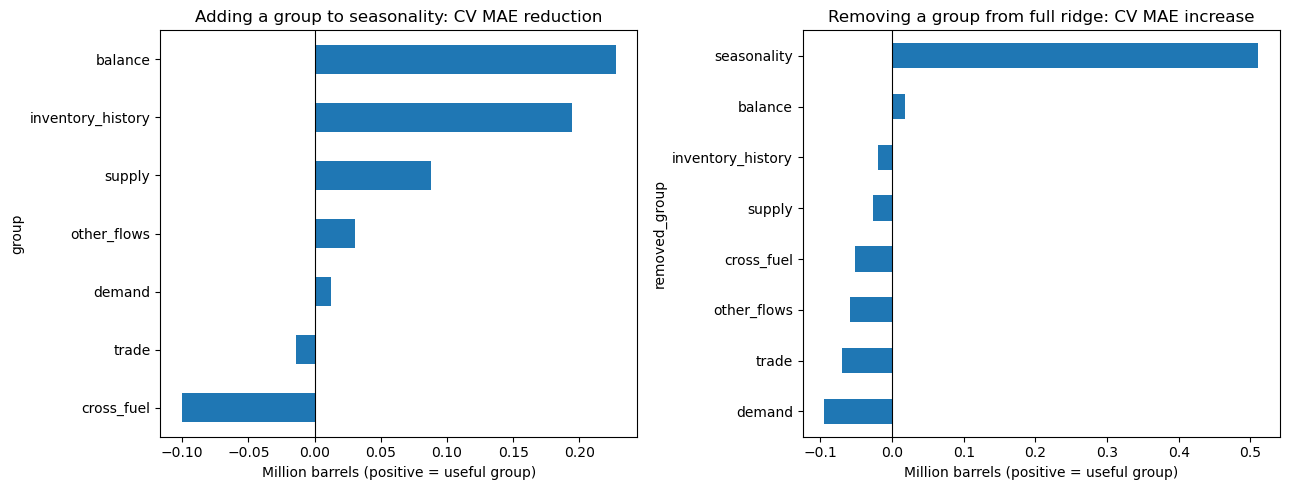

In [4]:
# Retrained group ablations: loss of skill after removing a group from full ridge.
full_name = min([f'all_ridge_{a}' for a in [1,10,100]], key=lambda k: metrics(cv_predictions[k])['mae_mb'])
full_alpha = specs[full_name][2]
full_mae = metrics(cv_predictions[full_name])['mae_mb']
ablation = []
for group in groups:
    p = evaluate([g for g in groups if g != group], alpha=full_alpha)
    ablation.append({'removed_group':group, 'mae_increase_mb':metrics(p)['mae_mb']-full_mae})
ablation = pd.DataFrame(ablation).sort_values('mae_increase_mb', ascending=False)
display(ablation)
# Individual additions, fixed calendar alpha: complements correlated group rankings.
individual = []
for group in list(groups)[1:]:
    for feature in groups[group]:
        groups['_single'] = [feature]
        p = evaluate(['seasonality', '_single'], alpha=specs[calendar_name][2])
        individual.append({'feature':feature, 'group':group, 'gain_vs_calendar_mb':calendar_mae-metrics(p)['mae_mb']})
del groups['_single']
individual = pd.DataFrame(individual).sort_values('gain_vs_calendar_mb', ascending=False)
display(individual.head(15))
fig, ax = plt.subplots(1,2,figsize=(13,5))
addition.set_index('group').gain_vs_calendar_mb.sort_values().plot.barh(ax=ax[0], title='Adding a group to seasonality: CV MAE reduction')
ablation.set_index('removed_group').mae_increase_mb.sort_values().plot.barh(ax=ax[1], title='Removing a group from full ridge: CV MAE increase')
for a in ax: a.axvline(0,color='black',lw=0.8); a.set_xlabel('Million barrels (positive = useful group)')
plt.tight_layout(); plt.show()


## Final-period check

July 2024–June 2026 tests the chosen specification, refitted monthly using earlier eligible observations. The period was reviewed previously in this project. The gain interval allows for some clustering of errors, but excludes uncertainty from model search and data revisions.

,candidate,mae_mb,rmse_mb,direction_accuracy,direction_call_coverage
0,forward2_other_flows_1,3.803788,5.471468,0.791667,1.0
1,calendar_ridge_1,3.638806,5.444252,0.875000,1.0
2,historical_month_mean,3.620093,5.426343,0.875000,1.0
3,zero_change,8.468792,10.655768,NaN,0.0
4,all_ridge_10,3.500630,5.119594,0.750000,1.0


Holdout MAE gain over calendar: -0.165 million barrels; descriptive 95% block-bootstrap interval [-0.707, 0.333]


,months,mae_mb
year,,
2024,6,3.335534
2025,12,3.126662
2026,6,5.626296


,availability,mae_mb,rmse_mb,direction_accuracy,direction_call_coverage
0,previous month (research assumption),3.803788,5.471468,0.791667,1.0
1,three-month lag (stress test),3.950992,5.879309,0.875000,1.0


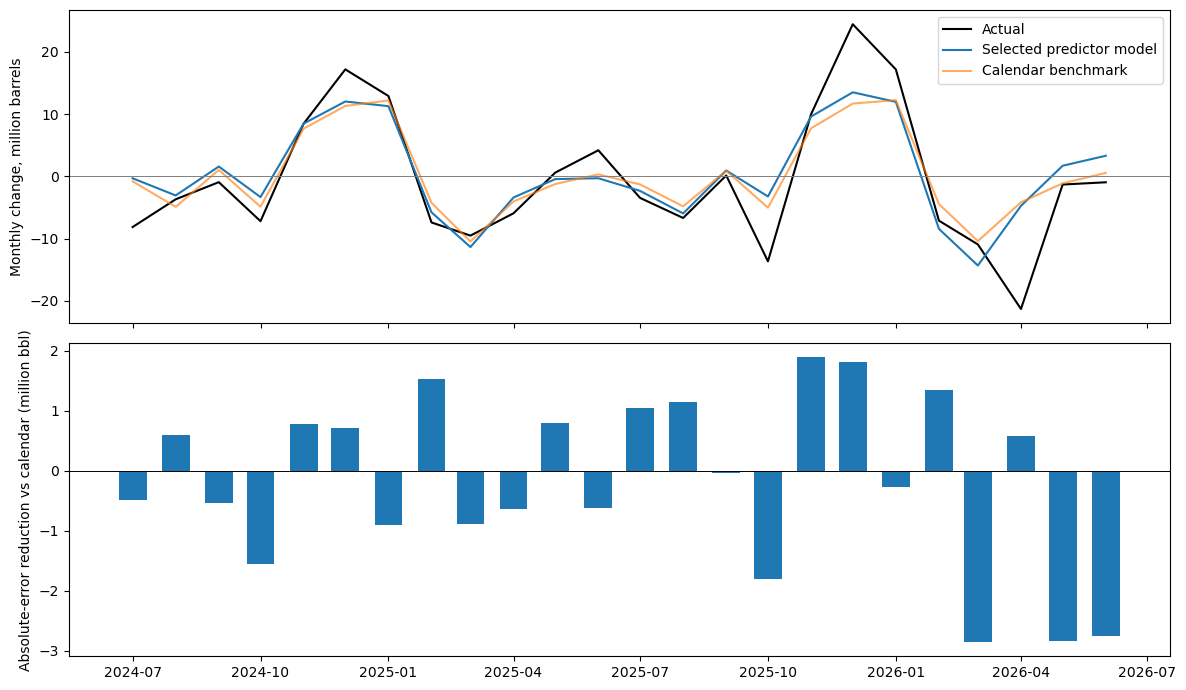

,month,fold,actual,predicted,calendar_prediction,absolute_error
0,2024-07-01,1,-8.138,-0.307669,-0.800613,7.830331
1,2024-08-01,2,-3.680,-3.061355,-4.897442,0.618645
2,2024-09-01,3,-0.927,1.582505,1.041124,2.509505
3,2024-10-01,4,-7.199,-3.324971,-4.870782,3.874029
4,2024-11-01,5,8.456,8.475071,7.664904,0.019071
5,2024-12-01,6,17.187,12.025376,11.308786,5.161624
6,2025-01-01,7,12.911,11.279294,12.189623,1.631706
7,2025-02-01,8,-7.400,-5.773062,-4.246263,1.626938
8,2025-03-01,9,-9.515,-11.347078,-10.455561,1.832078
9,2025-04-01,10,-5.929,-3.391713,-4.032569,2.537287


In [5]:
test_dates = X.index[X.index >= HOLDOUT]
assert len(test_dates) == 24
# Each month refit only on eligible observations preceding that target month.
monthly_blocks = [pd.DatetimeIndex([d]) for d in test_dates]
check_names = list(dict.fromkeys([winner, calendar_name, 'historical_month_mean', 'zero_change', full_name]))
test_predictions = {name:evaluate(*specs[name], blocks=monthly_blocks) for name in check_names}
test_metrics = pd.DataFrame([{'candidate':name, **metrics(p)} for name,p in test_predictions.items()])
display(test_metrics)
wp, bp = test_predictions[winner], test_predictions[calendar_name]
paired_gain = np.abs(bp.actual-bp.predicted).to_numpy()-np.abs(wp.actual-wp.predicted).to_numpy()
rng = np.random.default_rng(42)
# Circular three-month block bootstrap retains some serial dependence.
boots = []
for _ in range(3000):
    starts = rng.integers(0,len(paired_gain),size=8)
    ids = np.concatenate([(s+np.arange(3))%len(paired_gain) for s in starts])
    boots.append(paired_gain[ids].mean())
ci = np.quantile(boots,[0.025,0.975])
print(f'Holdout MAE gain over calendar: {paired_gain.mean():.3f} million barrels; descriptive 95% block-bootstrap interval [{ci[0]:.3f}, {ci[1]:.3f}]')
by_year = wp.assign(year=wp.month.dt.year, error=(wp.actual-wp.predicted).abs()).groupby('year').agg(months=('error','size'),mae_mb=('error','mean'))
display(by_year)
# Availability stress test: same feature definitions shifted two additional months.
# Map columns back to the original names; all noncalendar predictors become older.
X3, y3, groups3, eligible3 = make_design(lag=3)
X3.columns = X.columns
lag3 = evaluate(*specs[winner], blocks=monthly_blocks, design=(X3,y3,eligible3))
display(pd.DataFrame([{'availability':'previous month (research assumption)', **metrics(wp)},
                     {'availability':'three-month lag (stress test)', **metrics(lag3)}]))
fig, ax = plt.subplots(2,1,figsize=(12,7),sharex=True)
ax[0].plot(wp.month,wp.actual,label='Actual',color='black')
ax[0].plot(wp.month,wp.predicted,label='Selected predictor model')
ax[0].plot(bp.month,bp.predicted,label='Calendar benchmark',alpha=.65)
ax[0].axhline(0,color='grey',lw=.7); ax[0].set_ylabel('Monthly change, million barrels'); ax[0].legend()
ax[1].bar(wp.month,paired_gain,width=20); ax[1].axhline(0,color='black',lw=.7)
ax[1].set_ylabel('Absolute-error reduction vs calendar (million bbl)')
plt.tight_layout(); plt.show()
display(wp.assign(calendar_prediction=bp.predicted, absolute_error=(wp.actual-wp.predicted).abs()))


In [6]:
# Keep the trading readout tied to the current outputs.
wm, bm = metrics(wp)['mae_mb'], metrics(bp)['mae_mb']
gain = 100*(1-wm/bm)
comparison = 'lower' if gain >= 0 else 'higher'
display(Markdown(f"## Signal scorecard\n\n"
    f"Selected inputs: **{', '.join(specs[winner][0]).replace('_',' ')}**. "
    f"Final-period MAE is **{wm:.2f} million barrels**, versus **{bm:.2f} million** for calendar alone: "
    f"**{abs(gain):.1f}% {comparison} error**. "
    f"The descriptive 95% interval for the barrel-error gain is **[{ci[0]:.2f}, {ci[1]:.2f}] million barrels**. "
    + ("It spans zero, so an improvement is not clearly established." if ci[0] <= 0 <= ci[1] else "This short, previously reviewed sample still needs validation on new months.")))
rows=[]
for name,label in [(winner,'Selected signals'),(calendar_name,'Calendar'),('historical_month_mean','Historical seasonal mean'),('zero_change','Unchanged stocks')]:
    values=metrics(test_predictions[name])
    rows.append({'Method':label,'MAE (million bbl)':values['mae_mb'],
        'RMSE (million bbl)':values['rmse_mb'],
        'Build/draw hit rate (%)':100*values['direction_accuracy'],
        'Months with a direction call (%)':100*values['direction_call_coverage']})
display(pd.DataFrame(rows).drop_duplicates())
display(Markdown("A zero-change forecast makes no directional call, so its hit rate is blank. "
    "Hit rates score the sign of inventory change, not a price move. "
    f"With three-month-old inputs, the selected model's MAE is **{metrics(lag3)['mae_mb']:.2f} million barrels**. "
    "Check the yearly errors above for periods when the signal weakens; the first and last calendar years cover only part of a year."))


## Signal scorecard

Selected inputs: **seasonality, balance, other flows**. Final-period MAE is **3.80 million barrels**, versus **3.64 million** for calendar alone: **4.5% higher error**. The descriptive 95% interval for the barrel-error gain is **[-0.71, 0.33] million barrels**. It spans zero, so an improvement is not clearly established.

,Method,MAE (million bbl),RMSE (million bbl),Build/draw hit rate (%),Months with a direction call (%)
0,Selected signals,3.803788,5.471468,79.166667,100.0
1,Calendar,3.638806,5.444252,87.500000,100.0
2,Historical seasonal mean,3.620093,5.426343,87.500000,100.0
3,Unchanged stocks,8.468792,10.655768,NaN,0.0


A zero-change forecast makes no directional call, so its hit rate is blank. Hit rates score the sign of inventory change, not a price move. With three-month-old inputs, the selected model's MAE is **3.95 million barrels**. Check the yearly errors above for periods when the signal weakens; the first and last calendar years cover only part of a year.

## Before using the signal

Test on new releases with the data actually available at each forecast date. The three-month lag check is a sensitivity test, not a reconstruction of release timing. March 2020–March 2021 and training lookbacks touching that interval are excluded; sparse flows retain the source loaders' zero assumptions.

These notebooks fit national changes directly and refit monthly. The S&D notebooks fit regional stocks and sum them, with a different refit schedule. Their errors are not a matched comparison of methods. Direction accuracy is not trading P&L.

To rerun, keep both product folders under `oil/` with their data and loader modules. The cross-fuel inputs require both folders; a single cloned product repository is insufficient. The input hashes above identify the snapshots.